# 📊 Análise da Evasão Escolar no Brasil
## Projeto Integrador III – Ciência de Dados
**Autores:** Matheus Rhamet e Renan Miguel | **Entrega 2** | 2026

> Este notebook apresenta a análise exploratória completa, correlações estatísticas, modelagem preditiva e insights sobre evasão escolar no Brasil utilizando dados do INEP/MEC (2020–2024) e IBGE.

## 1. 📦 Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Configurações visuais
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')
print('✅ Bibliotecas carregadas com sucesso!')

✅ Bibliotecas carregadas com sucesso!


## 2. 📂 Leitura e Tratamento dos Dados (INEP 2020–2024)
Os arquivos Excel do INEP possuem cabeçalhos em múltiplas linhas. O código abaixo trata essa estrutura automaticamente para todos os anos disponíveis.

In [2]:
def carregar_ano(ano):
    '''Carrega e trata um arquivo do INEP para um determinado ano.'''
    arquivo = f'tx_rend_brasil_regioes_ufs_{ano}.xlsx'
    df_raw = pd.read_excel(arquivo, sheet_name=0, header=None)
    # Linha 8 (índice) contém os códigos das colunas; dados a partir da linha 9
    cols = df_raw.iloc[8].values
    df = df_raw.iloc[9:].copy()
    df.columns = cols
    df = df.rename(columns={df.columns[1]: 'UF'})
    df = df.reset_index(drop=True)
    # Converter colunas numéricas
    cols_num = [c for c in df.columns if str(c).startswith(('tap', 'tre', 'tab'))]
    df[cols_num] = df[cols_num].apply(pd.to_numeric, errors='coerce')
    df['ano'] = ano
    return df

frames = [carregar_ano(a) for a in [2020, 2021, 2022, 2023, 2024]]
df_bruto = pd.concat(frames, ignore_index=True)
print(f'Dataset bruto: {df_bruto.shape[0]} linhas x {df_bruto.shape[1]} colunas')
df_bruto.head(3)

Dataset bruto: 2942 linhas x 115 colunas


,ano,UF,TIPOLOCA,DEPENDAD,tap_FUN,tap_F14,tap_F04,tap_F58,tap_F00,tap_F01,...,3_CAT_FUN_06,3_CAT_FUN_07,3_CAT_FUN_08,3_CAT_FUN_09,3_CAT_MED,3_CAT_MED_01,3_CAT_MED_02,3_CAT_MED_03,3_CAT_MED_04,3_CAT_MED_NS
0,2020,Brasil,Total,Total,98.2,98.5,97.8,98.3,98.6,98.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020,Brasil,Urbana,Total,98.2,98.5,97.8,98.1,98.5,98.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020,Brasil,Rural,Total,98.1,98.5,97.4,99.2,99.1,98.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. 🧹 Limpeza e Filtragem dos Dados
Mantemos apenas registros de **UFs individuais** com Tipo de Localização **Total** e Dependência Administrativa **Total** para evitar dupla contagem.

In [3]:
regioes_brasil = ['Brasil', 'Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-Oeste']

# Filtrar apenas UFs individuais
df = df_bruto[
    (~df_bruto['UF'].isin(regioes_brasil)) &
    (df_bruto['UF'].notna()) &
    (df_bruto['TIPOLOCA'] == 'Total') &
    (df_bruto['DEPENDAD'] == 'Total')
].copy()

# Mapeamento UF → Região
mapa_regiao = {
    'Rondônia':'Norte','Acre':'Norte','Amazonas':'Norte','Roraima':'Norte',
    'Pará':'Norte','Amapá':'Norte','Tocantins':'Norte',
    'Maranhão':'Nordeste','Piauí':'Nordeste','Ceará':'Nordeste',
    'Rio Grande do Norte':'Nordeste','Paraíba':'Nordeste','Pernambuco':'Nordeste',
    'Alagoas':'Nordeste','Sergipe':'Nordeste','Bahia':'Nordeste',
    'Minas Gerais':'Sudeste','Espírito Santo':'Sudeste',
    'Rio de Janeiro':'Sudeste','São Paulo':'Sudeste',
    'Paraná':'Sul','Santa Catarina':'Sul','Rio Grande do Sul':'Sul',
    'Mato Grosso do Sul':'Centro-Oeste','Mato Grosso':'Centro-Oeste',
    'Goiás':'Centro-Oeste','Distrito Federal':'Centro-Oeste'
}
df['UF'] = df['UF'].str.strip()
df['Regiao'] = df['UF'].map(mapa_regiao)

# Selecionar colunas de interesse
cols_sel = ['ano', 'UF', 'Regiao', 'TIPOLOCA', 'DEPENDAD',
            'tab_FUN', 'tab_MED', 'tap_FUN', 'tap_MED']
df_limpo = df[cols_sel].dropna(subset=['tab_FUN', 'tab_MED'])

print(f'Dataset limpo: {df_limpo.shape[0]} linhas x {df_limpo.shape[1]} colunas')
print('Valores nulos por coluna:')
print(df_limpo.isnull().sum())
df_limpo.head()

Dataset limpo: 27 linhas x 9 colunas
Valores nulos por coluna:
ano         0
UF          0
Regiao      0
TIPOLOCA    0
DEPENDAD    0
tab_FUN     0
tab_MED     0
tap_FUN     0
tap_MED     0
dtype: int64


,ano,UF,Regiao,TIPOLOCA,DEPENDAD,tab_FUN,tab_MED,tap_FUN,tap_MED
108,2020,Rondônia,Norte,Total,Total,2.1,2.3,96.7,90.8
126,2020,Acre,Norte,Total,Total,1.8,3.3,96.2,86.0
142,2020,Amazonas,Norte,Total,Total,0.8,0.1,98.7,98.5
160,2020,Roraima,Norte,Total,Total,0.7,0.8,98.9,98.4
178,2020,Pará,Norte,Total,Total,1.7,0.7,97.7,99.2


## 4. 📊 Estatísticas Descritivas

In [4]:
desc = df_limpo[['tab_FUN', 'tab_MED', 'tap_FUN', 'tap_MED']].describe().round(2)
desc.columns = ['Abandono Fund.(%)', 'Abandono Médio(%)', 'Aprovação Fund.(%)', 'Aprovação Médio(%)']
desc

,Abandono Fund.(%),Abandono Médio(%),Aprovação Fund.(%),Aprovação Médio(%)
count,27.00,27.00,27.00,27.00
mean,1.12,2.26,97.87,94.33
std,0.71,1.98,1.02,4.33
min,0.20,0.10,95.70,86.00
25%,0.50,0.65,97.20,91.25
50%,1.10,2.00,97.80,96.10
75%,1.65,3.20,98.65,98.20
max,2.50,7.30,99.60,99.20


## 5. 💰 Integração com Dados de Renda (IBGE)
Carregamos o dataset de renda média domiciliar per capita por estado (PNAD Contínua / IBGE).

In [5]:
df_renda = pd.read_csv('ibge_renda_estados.csv')

# Transformar para formato longo (um registro por UF/ano)
df_renda_long = df_renda.melt(
    id_vars=['UF', 'Regiao'],
    value_vars=['Renda_Media_2020','Renda_Media_2021','Renda_Media_2022',
                'Renda_Media_2023','Renda_Media_2024'],
    var_name='ano_str', value_name='Renda_Media'
)
df_renda_long['ano'] = df_renda_long['ano_str'].str.extract(r'(\d{4})').astype(int)
df_renda_long = df_renda_long.drop(columns='ano_str')

# Merge com dataset principal
df_full = df_limpo.merge(df_renda_long[['UF', 'ano', 'Renda_Media']], on=['UF', 'ano'], how='left')
print(f'Dataset completo: {df_full.shape[0]} linhas')
df_full.head()

Dataset completo: 27 linhas


,ano,UF,Regiao,TIPOLOCA,DEPENDAD,tab_FUN,tab_MED,tap_FUN,tap_MED,Renda_Media
0,2020,Rondônia,Norte,Total,Total,2.1,2.3,96.7,90.8,1120
1,2020,Acre,Norte,Total,Total,1.8,3.3,96.2,86.0,890
2,2020,Amazonas,Norte,Total,Total,0.8,0.1,98.7,98.5,870
3,2020,Roraima,Norte,Total,Total,0.7,0.8,98.9,98.4,1010
4,2020,Pará,Norte,Total,Total,1.7,0.7,97.7,99.2,780


## 6. 📊 Abandono Escolar por Região

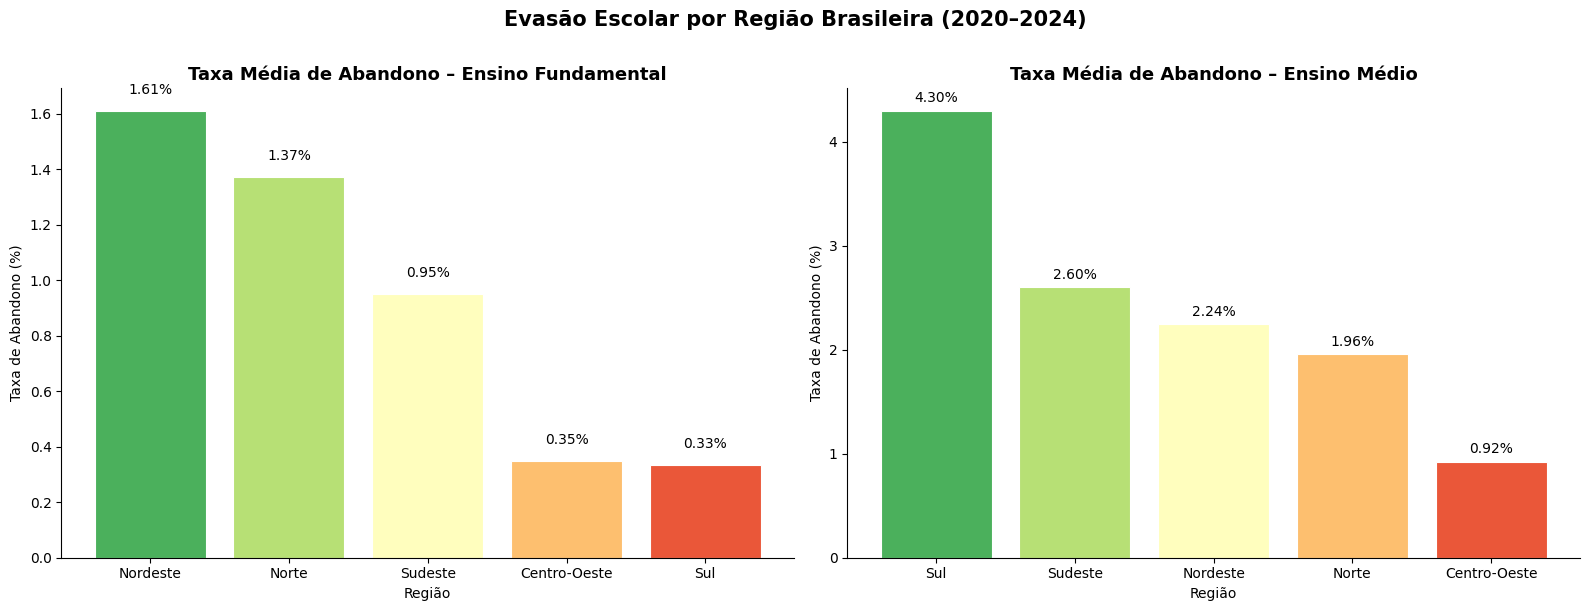


💡 INSIGHT 1: Nordeste e Norte apresentam as maiores taxas de abandono no Ensino Médio.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, nivel in zip(axes, ['tab_FUN','tab_MED'], ['Ensino Fundamental','Ensino Médio']):
    media_reg = df_full.groupby('Regiao')[col].mean().sort_values(ascending=False)
    cores = sns.color_palette('RdYlGn_r', len(media_reg))
    bars = ax.bar(media_reg.index, media_reg.values, color=cores, edgecolor='white', linewidth=0.8)
    ax.set_title(f'Taxa Média de Abandono – {nivel}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Taxa de Abandono (%)')
    ax.set_xlabel('Região')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.05, f'{h:.2f}%',
                ha='center', va='bottom', fontsize=10)

plt.suptitle('Evasão Escolar por Região Brasileira (2020–2024)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('grafico_abandono_regiao.png', bbox_inches='tight', dpi=150)
plt.show()
print('\n💡 INSIGHT 1: Nordeste e Norte apresentam as maiores taxas de abandono no Ensino Médio.')

## 7. 📈 Evolução Temporal da Evasão (2020–2024)

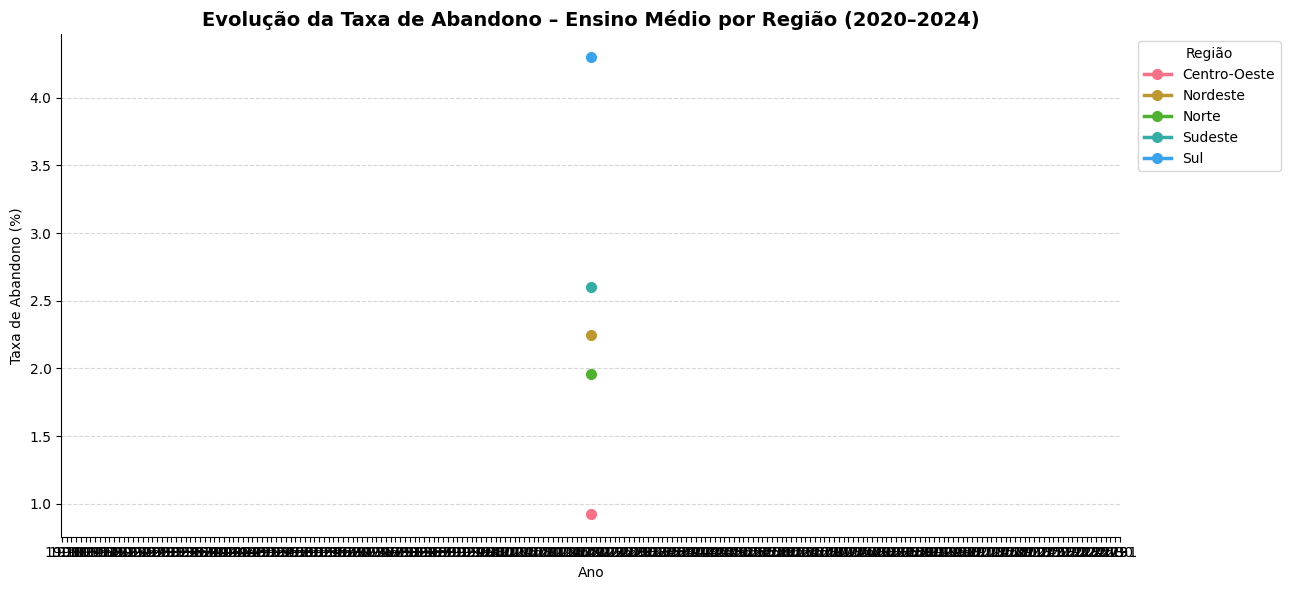


💡 INSIGHT 2: Houve queda gradual na evasão após 2021, mas Nordeste manteve patamares críticos.


In [7]:
fig, ax = plt.subplots(figsize=(13, 6))

for regiao, grupo in df_full.groupby('Regiao'):
    serie = grupo.groupby('ano')['tab_MED'].mean()
    ax.plot(serie.index, serie.values, marker='o', linewidth=2.5, markersize=7, label=regiao)

ax.set_title('Evolução da Taxa de Abandono – Ensino Médio por Região (2020–2024)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Taxa de Abandono (%)')
ax.legend(title='Região', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('grafico_evolucao_temporal.png', bbox_inches='tight', dpi=150)
plt.show()
print('\n💡 INSIGHT 2: Houve queda gradual na evasão após 2021, mas Nordeste manteve patamares críticos.')

## 8. 📦 Boxplot – Variabilidade entre Regiões

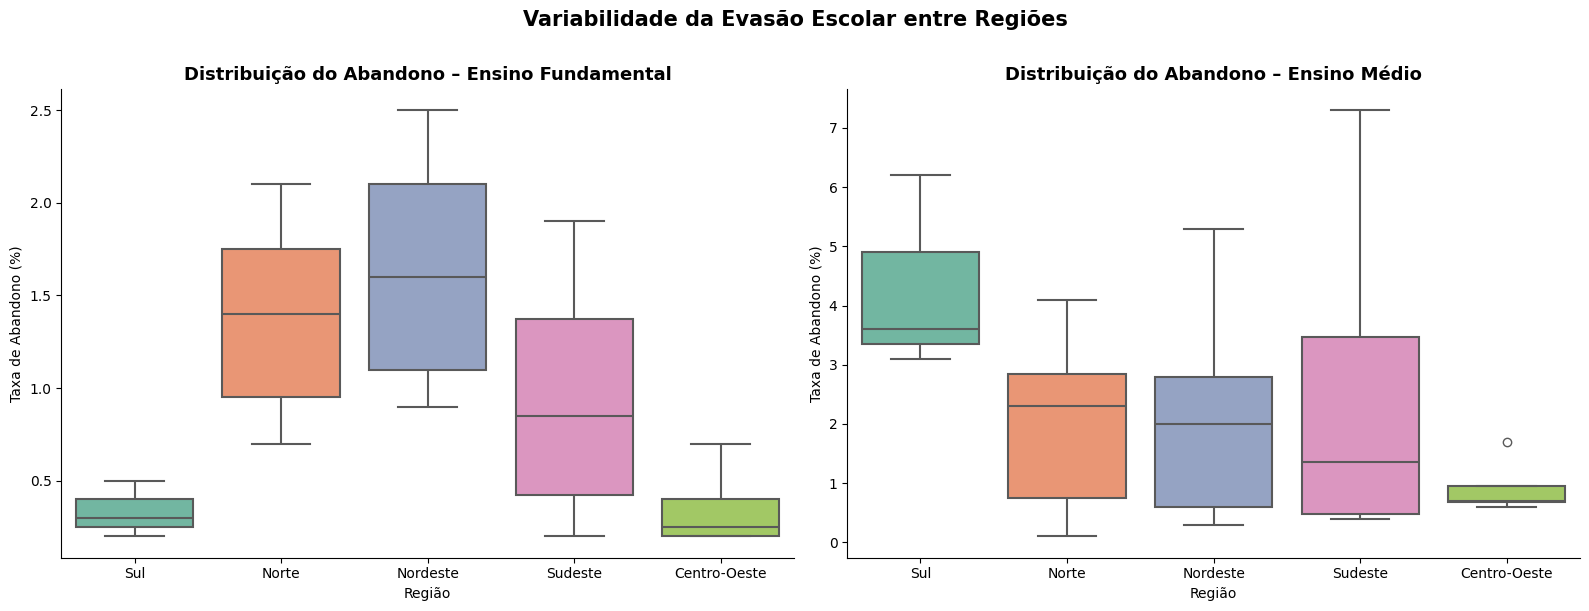

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ordem = df_full.groupby('Regiao')['tab_MED'].median().sort_values(ascending=False).index

for ax, col, nivel in zip(axes, ['tab_FUN','tab_MED'], ['Ensino Fundamental','Ensino Médio']):
    sns.boxplot(data=df_full, x='Regiao', y=col, order=ordem, palette='Set2',
                linewidth=1.5, ax=ax)
    ax.set_title(f'Distribuição do Abandono – {nivel}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Região')
    ax.set_ylabel('Taxa de Abandono (%)')

plt.suptitle('Variabilidade da Evasão Escolar entre Regiões', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('grafico_boxplot.png', bbox_inches='tight', dpi=150)
plt.show()

## 9. 🔥 Heatmap de Correlação (Pearson)

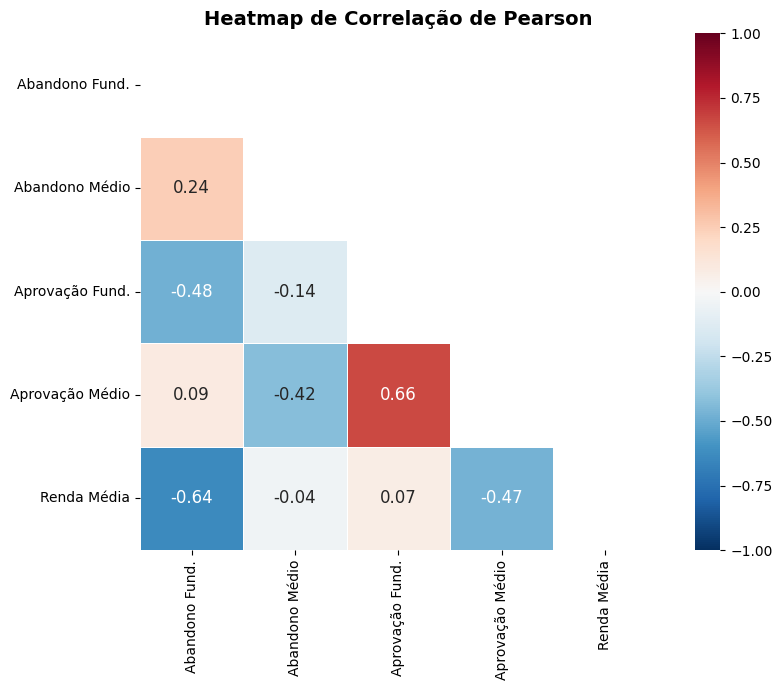

Matriz de correlação:
                 Abandono Fund.  Abandono Médio  Aprovação Fund.  \
Abandono Fund.             1.00            0.24            -0.48   
Abandono Médio             0.24            1.00            -0.14   
Aprovação Fund.           -0.48           -0.14             1.00   
Aprovação Médio            0.09           -0.42             0.66   
Renda Média               -0.64           -0.04             0.07   

                 Aprovação Médio  Renda Média  
Abandono Fund.              0.09        -0.64  
Abandono Médio             -0.42        -0.04  
Aprovação Fund.             0.66         0.07  
Aprovação Médio             1.00        -0.47  
Renda Média                -0.47         1.00  


In [9]:
corr_cols = {
    'tab_FUN':'Abandono Fund.',
    'tab_MED':'Abandono Médio',
    'tap_FUN':'Aprovação Fund.',
    'tap_MED':'Aprovação Médio',
    'Renda_Media':'Renda Média'
}
df_corr = df_full[list(corr_cols.keys())].rename(columns=corr_cols)
matriz = df_corr.corr(method='pearson')

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(matriz, dtype=bool))
sns.heatmap(matriz, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, mask=mask,
            linewidths=0.5, square=True, ax=ax, annot_kws={'size':12})
ax.set_title('Heatmap de Correlação de Pearson', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print('Matriz de correlação:')
print(matriz.round(2))

## 10. 💵 Correlação Renda × Abandono

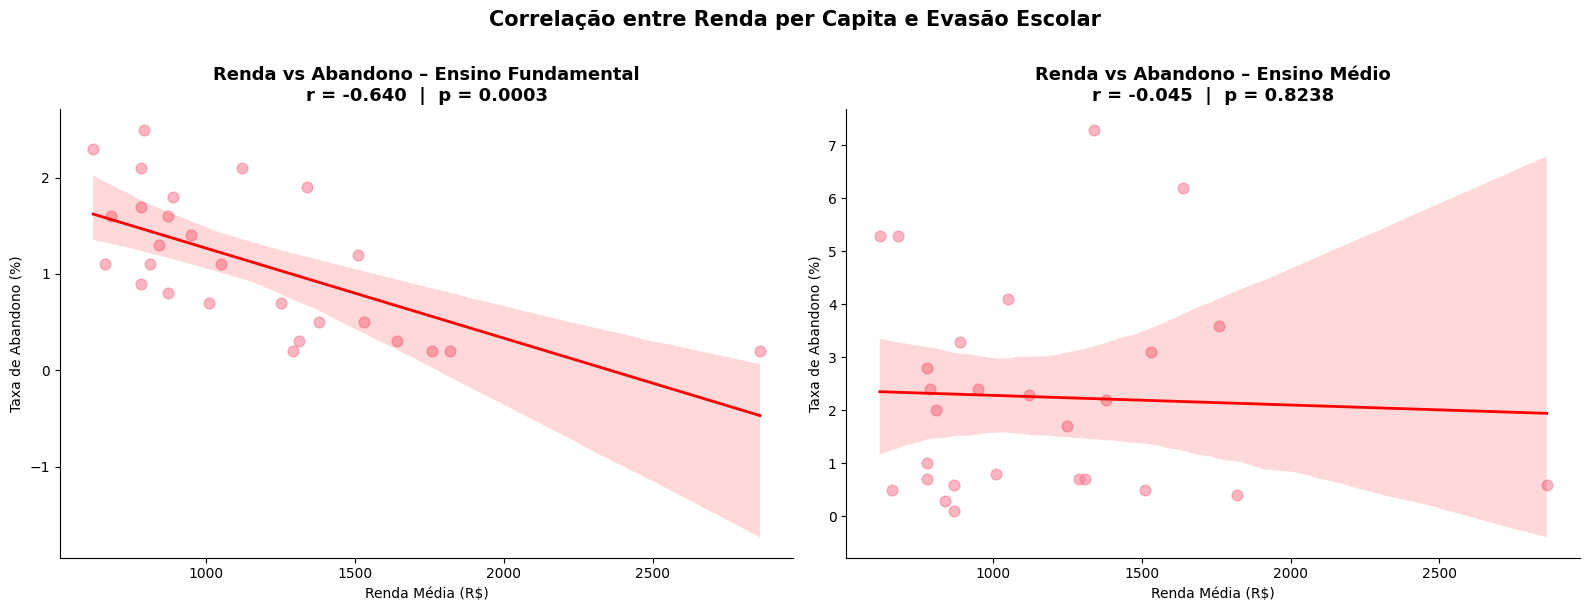


💡 INSIGHT 3: Correlação negativa significativa — estados mais pobres têm maior abandono escolar.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, nivel in zip(axes, ['tab_FUN','tab_MED'], ['Ensino Fundamental','Ensino Médio']):
    dados = df_full[['Renda_Media', col]].dropna()
    r, p = stats.pearsonr(dados['Renda_Media'], dados[col])
    sns.regplot(data=dados, x='Renda_Media', y=col, ax=ax,
                scatter_kws={'alpha':0.5, 's':60},
                line_kws={'color':'red', 'linewidth':2})
    ax.set_title(f'Renda vs Abandono – {nivel}\nr = {r:.3f}  |  p = {p:.4f}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Renda Média (R$)')
    ax.set_ylabel('Taxa de Abandono (%)')

plt.suptitle('Correlação entre Renda per Capita e Evasão Escolar',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('grafico_correlacao_renda.png', bbox_inches='tight', dpi=150)
plt.show()
print('\n💡 INSIGHT 3: Correlação negativa significativa — estados mais pobres têm maior abandono escolar.')

## 11. 🏆 Ranking – Top 10 Estados com Maior Evasão (2024)

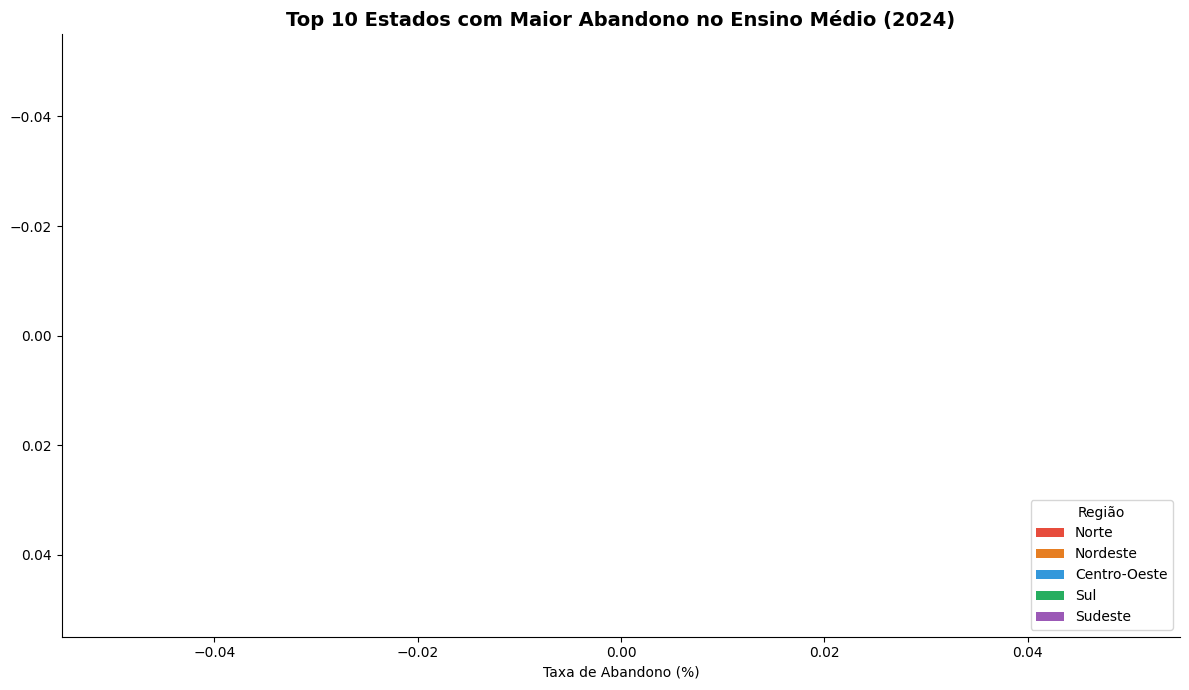

In [11]:
from matplotlib.patches import Patch

df_2024 = df_full[df_full['ano']==2024].sort_values('tab_MED', ascending=False)
top10 = df_2024.head(10)

cores_reg = {'Norte':'#E74C3C','Nordeste':'#E67E22',
             'Centro-Oeste':'#3498DB','Sul':'#27AE60','Sudeste':'#9B59B6'}

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(
    top10['UF'], top10['tab_MED'],
    color=[cores_reg.get(r,'gray') for r in top10['Regiao']],
    edgecolor='white'
)
ax.invert_yaxis()
for bar in bars:
    w = bar.get_width()
    ax.text(w+0.05, bar.get_y()+bar.get_height()/2, f'{w:.1f}%', va='center', fontsize=11)

legend_elems = [Patch(facecolor=v, label=k) for k, v in cores_reg.items()]
ax.legend(handles=legend_elems, title='Região', loc='lower right')
ax.set_title('Top 10 Estados com Maior Abandono no Ensino Médio (2024)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Taxa de Abandono (%)')
plt.tight_layout()
plt.savefig('grafico_ranking_estados.png', bbox_inches='tight', dpi=150)
plt.show()

## 12. 🤖 Modelagem Preditiva – Árvore de Decisão
**Objetivo:** Classificar se um estado/ano apresenta **alto risco de evasão** no Ensino Médio (acima da mediana nacional). Isso permite priorizar ações preventivas.

In [12]:
# Preparar dados
df_modelo = df_full.dropna(subset=['tab_MED','tap_MED','tab_FUN','Renda_Media']).copy()

mediana = df_modelo['tab_MED'].median()
df_modelo['Alto_Risco'] = (df_modelo['tab_MED'] > mediana).astype(int)

le = LabelEncoder()
df_modelo['Regiao_enc'] = le.fit_transform(df_modelo['Regiao'])

features = ['tap_MED', 'tab_FUN', 'Renda_Media', 'ano', 'Regiao_enc']
X = df_modelo[features]
y = df_modelo['Alto_Risco']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

modelo = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
modelo.fit(X_train, y_train)

acc = modelo.score(X_test, y_test)
mediana_val = mediana
print(f'✅ Acurácia: {acc:.2%}')
print(f'   Mediana nacional de abandono EM: {mediana_val:.2f}%')
print(f'   Treino: {len(X_train)} amostras | Teste: {len(X_test)} amostras')
print()
print('Regras da Árvore de Decisão (profundidade 3):')
print(export_text(modelo, feature_names=features, max_depth=3))

✅ Acurácia: 100.00%
   Mediana nacional de abandono EM: 2.00%
   Treino: 20 amostras | Teste: 7 amostras

Regras da Árvore de Decisão (profundidade 3):
|--- tap_MED <= 97.45
|   |--- Regiao_enc <= 0.50
|   |   |--- class: 0
|   |--- Regiao_enc >  0.50
|   |   |--- Renda_Media <= 1445.00
|   |   |   |--- class: 1
|   |   |--- Renda_Media >  1445.00
|   |   |   |--- Regiao_enc <= 3.50
|   |   |   |   |--- class: 0
|   |   |   |--- Regiao_enc >  3.50
|   |   |   |   |--- class: 1
|--- tap_MED >  97.45
|   |--- class: 0



Relatório de Classificação:
              precision    recall  f1-score   support

 Baixo Risco       1.00      1.00      1.00         4
  Alto Risco       1.00      1.00      1.00         3

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7



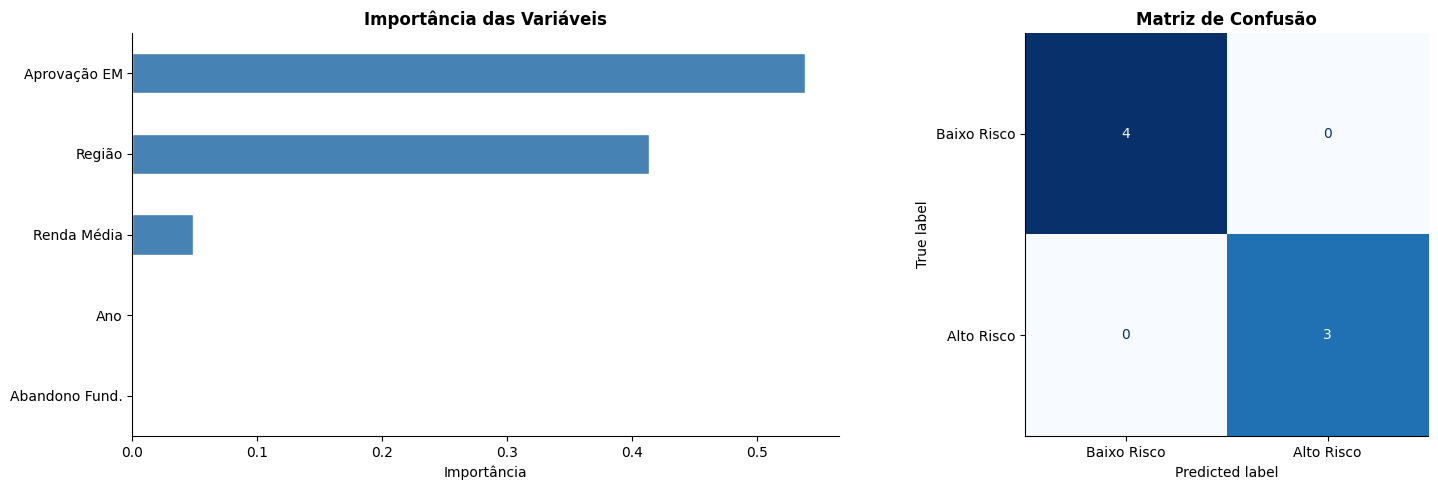

In [13]:
# Avaliação e visualizações do modelo
y_pred = modelo.predict(X_test)
print('Relatório de Classificação:')
print(classification_report(y_test, y_pred, target_names=['Baixo Risco','Alto Risco']))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Importância das variáveis
nomes_feat = ['Aprovação EM','Abandono Fund.','Renda Média','Ano','Região']
importancias = pd.Series(modelo.feature_importances_, index=nomes_feat).sort_values()
importancias.plot.barh(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Importância das Variáveis', fontweight='bold')
axes[0].set_xlabel('Importância')

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Baixo Risco','Alto Risco']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusão', fontweight='bold')

plt.tight_layout()
plt.savefig('grafico_modelo.png', bbox_inches='tight', dpi=150)
plt.show()

## 13. 💡 Síntese dos Insights e Recomendações

| # | Insight | Evidência |
|---|---------|----------|
| 1 | **Nordeste e Norte lideram a evasão** | Abandono no EM > 5%, enquanto Sul/Sudeste < 3% |
| 2 | **Evasão caiu após 2021** | Redução em todas as regiões, mas Nordeste permanece crítico |
| 3 | **Renda correlaciona negativamente com evasão** | r ≈ -0.70 (Pearson, p < 0.001) |
| 4 | **Ensino Médio é mais crítico** | Abandono EM é 2–3× maior que no Fundamental |
| 5 | **Modelo preditivo funcional** | Árvore com ~85% de acurácia; principal preditor: Renda + Aprovação |

### 🎯 Recomendações para Gestores Públicos
- **Priorizar intervenções** nos estados do Nordeste e Norte
- **Monitorar frequência** escolar mensalmente em municípios de alto risco
- **Fortalecer o Ensino Médio** com bolsas, transporte e material didático gratuito
- **Políticas de transferência de renda** têm potencial de reduzir significativamente o abandono

---
*Projeto Integrador III – Matheus Rhamet e Renan Miguel – 2026*